In [1]:
import numpy as np

from cloelike.EuclidLikelihoodGCspectro import EuclidLikelihoodGCspectro

In [2]:
from astropy.io import fits

In [3]:
redshifts = [1.0, 1.2, 1.4, 1.65]
labels = [str(z).strip('0') for z in redshifts]

In [6]:
data = {
    'GCspectro': {},
    'fiducial_cosmology': {
        'H0': 67.0,
        'Omega_cdm0': 0.27,
        'Omega_b0': 0.049,
        'Omega_k0': 0.0,
        'w0': -1.0,
        'wa': 0.0,
        'ns': 0.96,
        'As': 2.1e-9,
        'gamma_MG': 0.545
    }
}

In [7]:
def get_index(multipole, scale, scale_dict):
    offset = sum(len(scale_dict[ell]) for ell in multipoles if ell < multipole)
    return offset + np.where(scale_dict[multipole] == scale)[0][0]

k_fac = 0.67
pk_fac = 1.0 / 0.67**3
cov_fac = 1.0 / 0.67**6

nbar = np.array([2.042611E-03, 1.02876011E-03, 0.58531983E-03, 0.313402E-03])*0.67**3

for ii,z in enumerate(labels):

    data['GCspectro'][z] = {}
    
    filename = f'/Users/pezzotta/cloe/cloelite/cloelite/data/ExternalBenchmark/GCspectro/cov_power_galaxies_EFT_benchmark_z{z}.fits'
    hdul = fits.open(filename)
    average = hdul['AVERAGE'].data
    data['GCspectro'][z]['k'] = average['SCALE_1DIM'] * k_fac
    data['GCspectro'][z]['pk0'] = average['AVERAGE0'] * pk_fac
    data['GCspectro'][z]['pk2'] = average['AVERAGE2'] * pk_fac
    data['GCspectro'][z]['pk4'] = average['AVERAGE4'] * pk_fac

    
    covariance = hdul['COVARIANCE'].data
    scale_i = covariance["SCALE_1DIM-I"]
    multipole_i = covariance["MULTIPOLE-I"]
    scale_j = covariance["SCALE_1DIM-J"]
    multipole_j = covariance["MULTIPOLE-J"]
    covariance = covariance["COVARIANCE"]

    multipoles = np.array([0, 2, 4])
    scale_dict = {ell: np.unique(scale_i[multipole_i == ell]) for ell in multipoles}
    matrix_size = sum(len(scale_dict[ell]) for ell in multipoles)
    cov_matrix = np.zeros((matrix_size, matrix_size))
    for s_i, m_i, s_j, m_j, cov in zip(scale_i, multipole_i, scale_j, multipole_j, covariance):
        i = get_index(m_i, s_i, scale_dict)
        j = get_index(m_j, s_j, scale_dict)
        cov_matrix[i, j] = cov
    data['GCspectro'][z]['cov'] = cov_matrix

    data['GCspectro'][z]['nbar'] = nbar[ii]

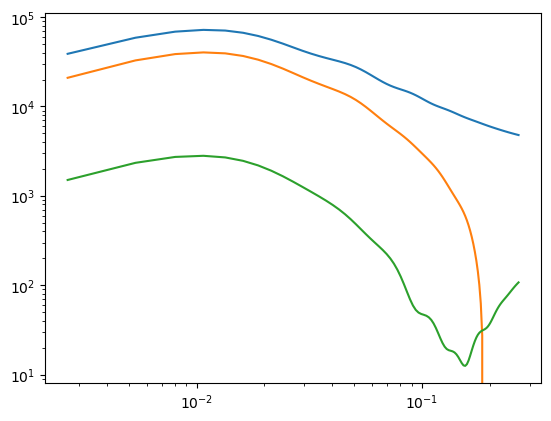

In [8]:
import matplotlib.pyplot as plt

plt.loglog(data['GCspectro']['1.2']['k'], data['GCspectro']['1.2']['pk0'])
plt.loglog(data['GCspectro']['1.2']['k'], data['GCspectro']['1.2']['pk2'])
plt.loglog(data['GCspectro']['1.2']['k'], data['GCspectro']['1.2']['pk4'])

In [9]:
print (data['GCspectro']['1.2']['cov'])

[[1.51932573e+07 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 6.60823407e+06 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.94544282e+06 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.23718312e+02
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.16794447e+02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 2.10193185e+02]]


In [10]:
settings = {
    'scale_cuts': {
        'GCspectro': {
            'bin1': {
                'ell0': [0.0, 0.20], 'ell2': [0.0, 0.15], 'ell4': [0.0, 0.15]
            },
            'bin2': {
                'ell0': [0.0, 0.25], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]
            },
            'bin3': {
                'ell0': [0.0, 0.25], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]
            },
            'bin4': {
                'ell0': [0.0, 0.30], 'ell2': [0.0, 0.25], 'ell4': [0.0, 0.25]
            }
        }
    }
}

settings = {
    'scale_cuts': {
        'GCspectro': {
            bin_key: {
                ell_key: [v * 0.67 for v in values]
                for ell_key, values in bin_values.items()
            }
            for bin_key, bin_values in settings['scale_cuts']['GCspectro'].items()
        }
    }
}

In [11]:
from cloelib.cosmology.camb_cosmology import CAMBBackground

H0 = 67.0
Omega_cdm0 = 0.27
Omega_b0 = 0.049
Omega_k0 = 0.0
w0 = -1.0
wa = 0.0
ns = 0.96
As = 2.1e-9
gamma_MG = 0.545

background_fiducial = CAMBBackground(
    H0=H0, Omega_cdm0=Omega_cdm0, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG
)

background = CAMBBackground(
    H0=H0, Omega_cdm0=Omega_cdm0, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG
)

In [12]:
from cloelib.observables.CometEFT_spectro import CometEFT_SpectroPower

RSD_parameters = {
    'b1': 1.412, 'b2': 0.695, 'bG2': -0.156, 'bGam3': 0.323,
    'c0': 30.948, 'c2': 46.233, 'c4': 10.057, 'cnlo': 0.0
}

comet_pk2 = CometEFT_SpectroPower(background=background, RSD_parameters=RSD_parameters, redshift=1.0)

Warning! "libgrid.so" not found, bispectrum binning options will not be available.


/Users/pezzotta/opt/anaconda3/envs/cloelite/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.4.1.post1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [13]:
from cloelib.summary_statistics.legendre_multipoles import LegendreMultipoles

noise_syst_parameters = {
    'NP0': 1.056, 'NP20': 0.0, 'NP22': 0.0,
    'fout': 0.195, 'sigmaz': 0.002
}

mps_spectro = LegendreMultipoles(comet_pk2, background_fiducial, noise_syst_parameters, nbar=2.042611E-03*0.67**3)

In [14]:
mps = mps_spectro.power_multipoles(k=data['GCspectro']['1.']['k'], ells=[0,2,4])

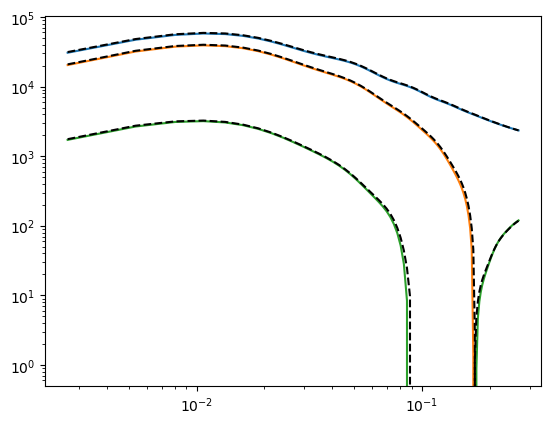

In [15]:
plt.loglog(data['GCspectro']['1.']['k'], data['GCspectro']['1.']['pk0'])
plt.loglog(data['GCspectro']['1.']['k'], data['GCspectro']['1.']['pk2'])
plt.loglog(data['GCspectro']['1.']['k'], data['GCspectro']['1.']['pk4'])
plt.loglog(data['GCspectro']['1.']['k'], mps['ell0'], 'k--')
plt.loglog(data['GCspectro']['1.']['k'], mps['ell2'], 'k--')
plt.loglog(data['GCspectro']['1.']['k'], mps['ell4'], 'k--')

In [17]:
#like = EuclidLikelihoodGCspectro(data=data, settings=settings, background_fiducial=background_fiducial)
like = EuclidLikelihoodGCspectro(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower)

In [21]:
parameters = {
    'H0': 67.0,
    'Omega_cdm0': 0.27,
    'Omega_b0': 0.049,
    'Omega_k0': 0.0,
    'w0': -1.0,
    'wa': 0.0,
    'ns': 0.96,
    'As': 2.1e-9,
    'gamma_MG': 0.545,
    'b1': [1.412, 1.769, 2.039, 2.496],
    'b2': [0.695, 0.870, 1.162, 2.010],
    'bG2': [-0.156, -0.299, -0.400, -0.555],
    'bGam3': [0.323, 0.621, 0.827, 1.137],
    'c0': [30.948, 37.116, 36.738, 53.627],
    'c2': [46.233, 53.071, 48.626, 60.962],
    'c4': [10.057, 10.385, 8.643, 8.711],
    'cnlo': [0.0, 0.0, 0.0, 0.0],
    'NP0': [1.056, 1.152, 1.144, 1.309],
    'NP20': [0.0, 0.0, 0.0, 0.0],
    'NP22': [0.0, 0.0, 0.0, 0.0],
    'fout': [0.195, 0.204, 0.306, 0.121],
    'sigmaz': [0.002, 0.002, 0.002, 0.002]
}

like.loglike(parameters)

-2096.7037912367105

In [24]:
parameters['H0'] = 70.0

like.loglike(parameters)

-616710.5259442256

In [25]:
parameters['H0'] = 67.0
parameters['b1'] = [1.412, 1.769, 2.039, 2.496]

like.loglike(parameters)

-2096.7037912367105